In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
#Data understanding
#Check data type
df= pd.read_csv('garments_worker_productivity.csv')

df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [3]:
print("Info:") # data types and non-null 
df.info()
('\n')
print("Shape:", df.shape) #dimension 

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dty

In [4]:
print("Missing Values:")
print(df.isnull().sum()) #find missing value

Missing Values:
date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


In [5]:
print("\nStatistics summary:")
df.describe()


Statistics summary:


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


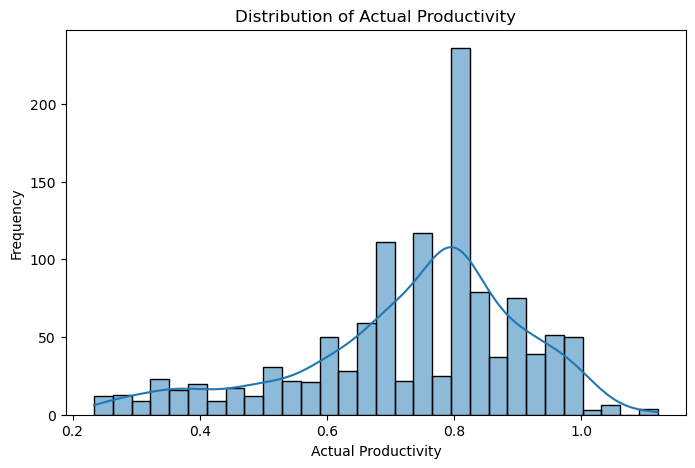

In [6]:
#Exploratory Data Analysis
#Target variable distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["actual_productivity"], bins=30, kde=True) #Kernel Density Estimation
plt.title("Distribution of Actual Productivity")
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")
plt.show()

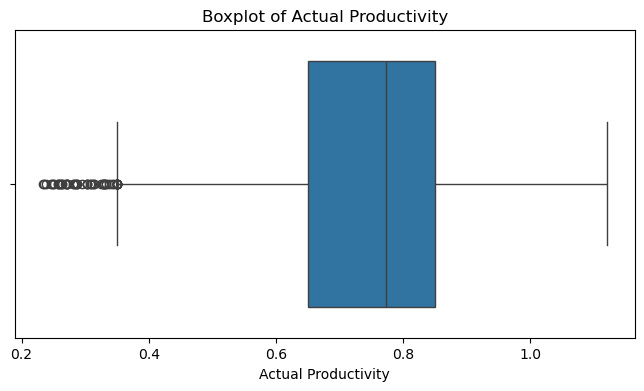

In [7]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["actual_productivity"])
plt.title("Boxplot of Actual Productivity")
plt.xlabel("Actual Productivity")
plt.show()

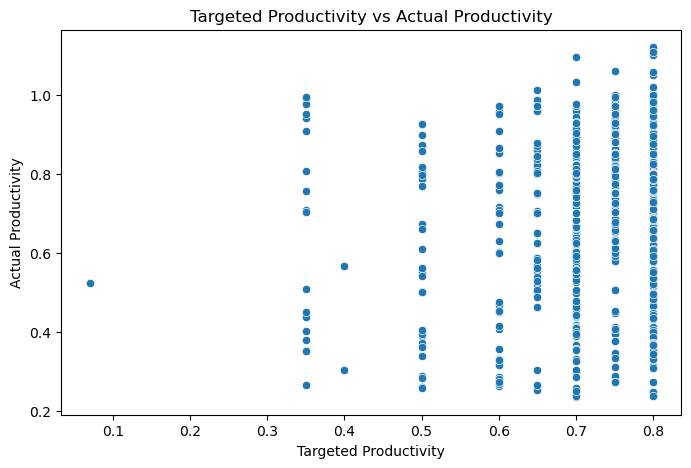

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="targeted_productivity", y="actual_productivity", data=df)
plt.title("Targeted Productivity vs Actual Productivity")
plt.xlabel("Targeted Productivity")
plt.ylabel("Actual Productivity")
plt.show()

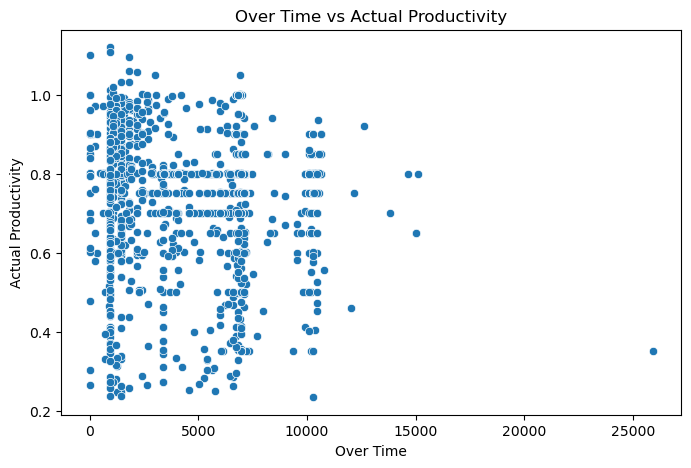

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="over_time", y="actual_productivity", data=df)
plt.title("Over Time vs Actual Productivity")
plt.xlabel("Over Time")
plt.ylabel("Actual Productivity")
plt.show()

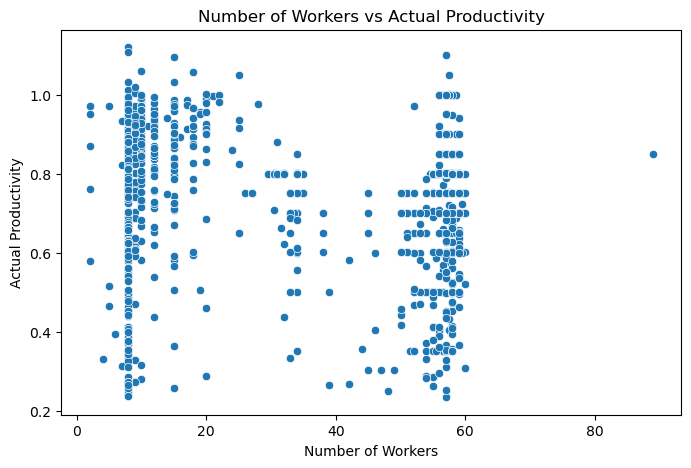

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="no_of_workers", y="actual_productivity", data=df)
plt.title("Number of Workers vs Actual Productivity")
plt.xlabel("Number of Workers")
plt.ylabel("Actual Productivity")
plt.show()

# Explanation:
# This plot shows the relationship between the number of workers and actual productivity.
# The clustered pattern suggests that productivity varies across different team sizes,
# and increasing the number of workers does not always lead to higher productivity.
# This may indicate coordination challenges or diminishing returns in larger teams.

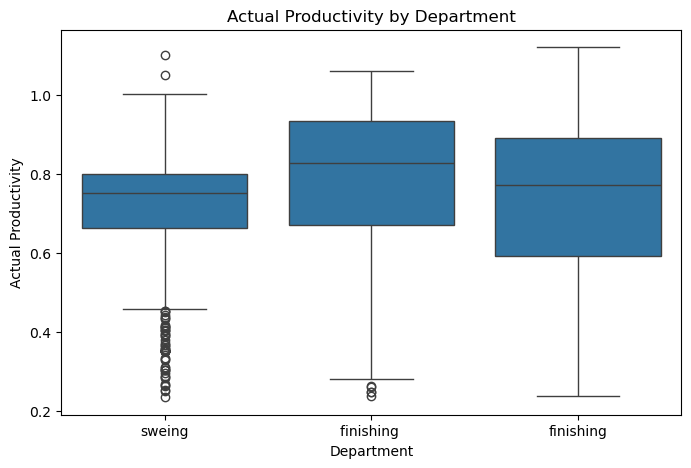

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="department", y="actual_productivity", data=df)
plt.title("Actual Productivity by Department")
plt.xlabel("Department")
plt.ylabel("Actual Productivity")
plt.show()

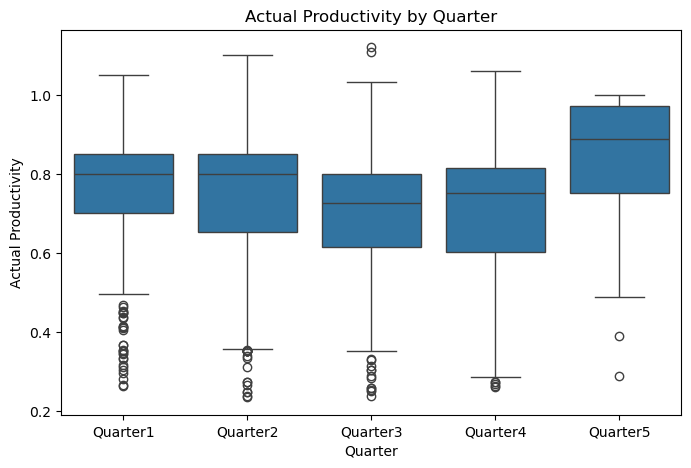

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="quarter", y="actual_productivity", data=df)
plt.title("Actual Productivity by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Actual Productivity")
plt.show()

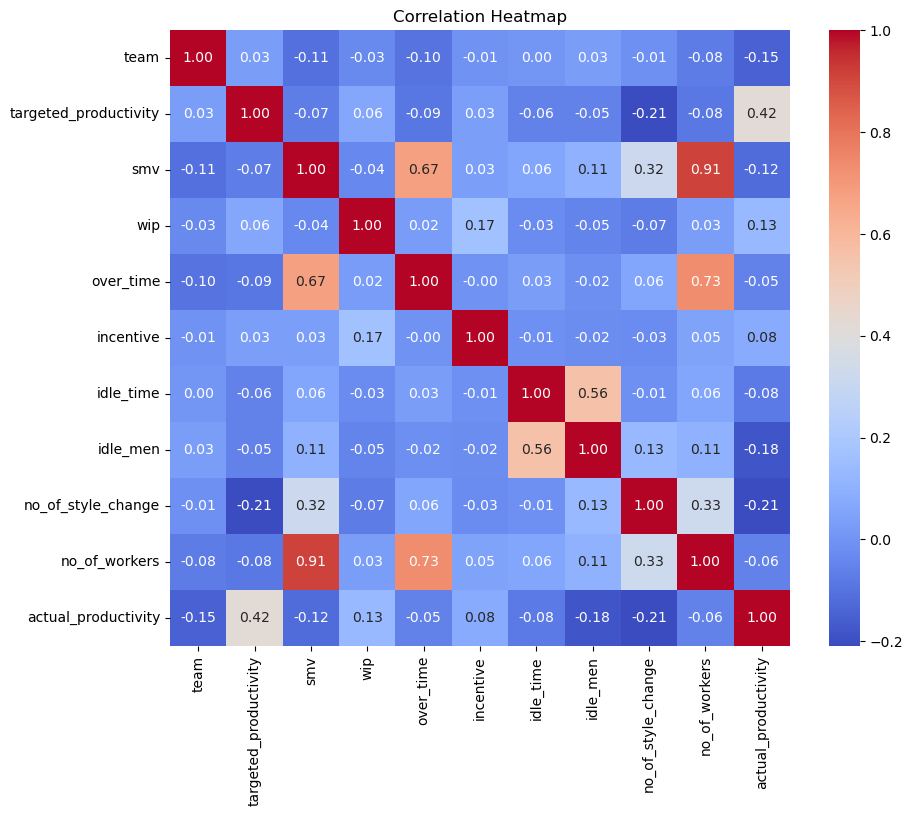

In [13]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#The correlation heatmap highlights the strength and direction of relationships among 
#numerical variables, supporting feature selection and model interpretation.

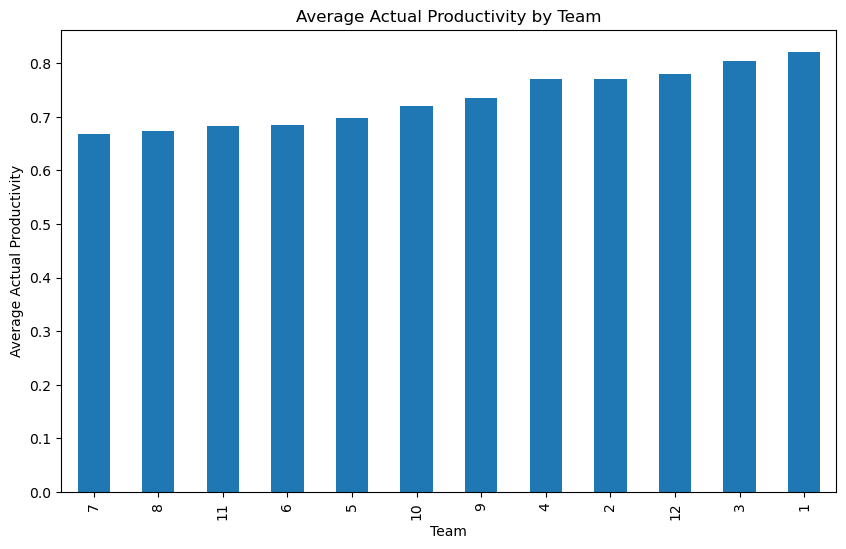

In [14]:
team_avg = df.groupby("team")["actual_productivity"].mean().sort_values()

plt.figure(figsize=(10,6))
team_avg.plot(kind="bar")
plt.title("Average Actual Productivity by Team")
plt.xlabel("Team")
plt.ylabel("Average Actual Productivity")
plt.show()

#Team-level average productivity reveals performance differences across teams and may 
#support operational benchmarking.

In [15]:
#5.0 Data preparation
print(df.columns)

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')


In [16]:
df['department'] = df['department'].astype(str) #String
df['department'] = df['department'].str.strip() #Remove space 
df['department'] = df['department'].str.lower() #Lowercase 
print(df['department'].value_counts())

department
sweing       691
finishing    506
Name: count, dtype: int64


In [17]:
#correct sweing -> sewing
df['department'] = df['department'].replace({'sweing':'sewing'})
print(df['department'])

0          sewing
1       finishing
2          sewing
3          sewing
4          sewing
          ...    
1192    finishing
1193    finishing
1194    finishing
1195    finishing
1196    finishing
Name: department, Length: 1197, dtype: object


In [18]:
df['wip'] = df['wip'].fillna(0)
print(df['wip'].isnull().sum()) #check 

0


In [19]:
print (df['wip'])

0       1108.0
1          0.0
2        968.0
3        968.0
4       1170.0
         ...  
1192       0.0
1193       0.0
1194       0.0
1195       0.0
1196       0.0
Name: wip, Length: 1197, dtype: float64


In [20]:
df['date'] = pd.to_datetime(df['date'], errors="coerce") #Datetime variable, invalid date values are converted to missing values

print(df.dtypes) 

date                     datetime64[ns]
quarter                          object
department                       object
day                              object
team                              int64
targeted_productivity           float64
smv                             float64
wip                             float64
over_time                         int64
incentive                         int64
idle_time                       float64
idle_men                          int64
no_of_style_change                int64
no_of_workers                   float64
actual_productivity             float64
dtype: object


In [21]:
df["day"] = df["date"].dt.day_name() #Date connect with day
print(df[["date", "day"]])

           date        day
0    2015-01-01   Thursday
1    2015-01-01   Thursday
2    2015-01-01   Thursday
3    2015-01-01   Thursday
4    2015-01-01   Thursday
...         ...        ...
1192 2015-03-11  Wednesday
1193 2015-03-11  Wednesday
1194 2015-03-11  Wednesday
1195 2015-03-11  Wednesday
1196 2015-03-11  Wednesday

[1197 rows x 2 columns]


In [22]:
df['actual_productivity'].describe() #Knowing Target variable statistics

count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

In [23]:
df[df['actual_productivity'] > 1] #find overproductivity
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,2015-01-01,Quarter1,sewing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,2015-01-01,Quarter1,finishing,Thursday,1,0.75,3.94,0.0,960,0,0.0,0,0,8.0,0.886500
2,2015-01-01,Quarter1,sewing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,2015-01-01,Quarter1,sewing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,2015-01-01,Quarter1,sewing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [24]:
def outliers_iqr(ys): #using +-1.5x IQR method for defining outliers

    quartile_1, quartile_3 = np.percentile(ys, [25, 75])
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 1.5)
    upper_bound = quartile_3 + (iqr * 1.5)
    return np.where((ys > upper_bound) | (ys < lower_bound))

pos = outliers_iqr(df.actual_productivity) #54
pos

(array([  60,  125,  146,  147,  169,  215,  237,  255,  256,  257,  258,
         298,  317,  336,  392,  414,  415,  436,  455,  496,  497,  541,
         560,  577,  578,  579,  689,  690,  691,  748,  765,  783,  784,
         801,  802,  822,  840,  841,  842,  843,  863,  882,  883,  920,
         921,  963,  984, 1024, 1045, 1046, 1067, 1086, 1127, 1149]),)

In [25]:
df.iloc[pos[0]] #outliers location 

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
60,2015-01-04,Quarter1,finishing,Sunday,11,0.75,4.15,0.0,960,0,0.0,0,0,8.0,0.345833
125,2015-01-07,Quarter1,finishing,Wednesday,5,0.70,4.15,0.0,1440,0,0.0,0,0,8.0,0.330114
146,2015-01-08,Quarter2,sewing,Thursday,11,0.35,12.52,287.0,25920,38,0.0,0,0,54.0,0.349951
147,2015-01-08,Quarter2,sewing,Thursday,5,0.70,42.41,724.0,10260,0,0.0,0,0,57.0,0.233705
169,2015-01-10,Quarter2,finishing,Saturday,5,0.50,4.15,0.0,1440,0,0.0,0,0,8.0,0.337973
215,2015-01-12,Quarter2,finishing,Monday,10,0.80,3.94,0.0,1440,0,0.0,0,0,8.0,0.246250
237,2015-01-13,Quarter2,sewing,Tuesday,10,0.35,22.40,715.0,10170,23,0.0,0,0,56.5,0.350206
255,2015-01-14,Quarter2,sewing,Wednesday,11,0.35,14.61,838.0,7200,23,0.0,0,0,55.0,0.350031
256,2015-01-14,Quarter2,finishing,Wednesday,10,0.80,3.94,0.0,1260,0,0.0,0,0,8.0,0.332359
257,2015-01-14,Quarter2,sewing,Wednesday,2,0.80,51.02,1086.0,4260,27,0.0,0,0,57.0,0.311207


In [26]:
df = pd.get_dummies(df, columns=['quarter','department','day'], drop_first=True) #dummy encode

print(df.columns)
print(df.shape) #Encoding left 1,0 for model analysis
df.head()

Index(['date', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time',
       'incentive', 'idle_time', 'idle_men', 'no_of_style_change',
       'no_of_workers', 'actual_productivity', 'quarter_Quarter2',
       'quarter_Quarter3', 'quarter_Quarter4', 'quarter_Quarter5',
       'department_sewing', 'day_Saturday', 'day_Sunday', 'day_Thursday',
       'day_Tuesday', 'day_Wednesday'],
      dtype='object')
(1197, 22)


,date,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,...,quarter_Quarter2,quarter_Quarter3,quarter_Quarter4,quarter_Quarter5,department_sewing,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,2015-01-01,8,0.80,26.16,1108.0,7080,98,0.0,0,0,...,False,False,False,False,True,False,False,True,False,False
1,2015-01-01,1,0.75,3.94,0.0,960,0,0.0,0,0,...,False,False,False,False,False,False,False,True,False,False
2,2015-01-01,11,0.80,11.41,968.0,3660,50,0.0,0,0,...,False,False,False,False,True,False,False,True,False,False
3,2015-01-01,12,0.80,11.41,968.0,3660,50,0.0,0,0,...,False,False,False,False,True,False,False,True,False,False
4,2015-01-01,6,0.80,25.90,1170.0,1920,50,0.0,0,0,...,False,False,False,False,True,False,False,True,False,False


In [27]:
df = df.drop(columns=['date']) #delete unnecessary variable

In [28]:
df.columns = df.columns.str.strip() #Make sure no space
print (df.columns)

Index(['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
       'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
       'actual_productivity', 'quarter_Quarter2', 'quarter_Quarter3',
       'quarter_Quarter4', 'quarter_Quarter5', 'department_sewing',
       'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday',
       'day_Wednesday'],
      dtype='object')


In [49]:
#6.0 Model requirement 
#Regression analysis
X_df = df.drop('actual_productivity', axis=1) #drop for the prediction
y_df = df['actual_productivity']

print(X_df.shape) #confirm x and y is separate 
print(y_df.shape)
print(X_df.columns) #cannot include actual_productivity avoid cheating

(1197, 20)
(1197,)
Index(['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
       'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
       'quarter_Quarter2', 'quarter_Quarter3', 'quarter_Quarter4',
       'quarter_Quarter5', 'department_sewing', 'day_Saturday', 'day_Sunday',
       'day_Thursday', 'day_Tuesday', 'day_Wednesday'],
      dtype='object')


In [50]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X_df, y_df,test_size=0.2, random_state=42)

print(Xtrain.shape) #957 training
print(Xtest.shape) #240 testing

(957, 20)
(240, 20)


In [51]:
results = []

In [52]:
#baseline (dummyregressor)
baseline = DummyRegressor(strategy="mean") #Build baseline mode (predict mean)
baseline.fit(Xtrain, ytrain) #Training through y and x

y_pred_base = baseline.predict(Xtest) #use data(test) predict
mae = mean_absolute_error(ytest, y_pred_base)
rmse = np.sqrt(mean_squared_error(ytest, y_pred_base))
r2 = r2_score(ytest, y_pred_base)

cv_rmse = -cross_val_score(baseline, Xtrain, ytrain, cv=5,scoring="neg_root_mean_squared_error").mean()
cv_r2 = cross_val_score(baseline, Xtrain, ytrain, cv=5,scoring="r2").mean()

print("Baseline Results:")
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2:", round(r2,4))

results.append({
    "Model": "Baseline",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "CV_RMSE": cv_rmse,
    "CV_R2": cv_r2,
    "Best Parameters": "Mean strategy"
})

Baseline Results:
MAE: 0.1274
RMSE: 0.1635
R2: -0.0064


In [53]:
#1. model (Linear Regression)
linreg = LinearRegression() # Build model
linreg.fit(Xtrain, ytrain) # Train
y_pred_lin = linreg.predict(Xtest) # Predict and from 1197 record find related average 

# Evaluate (sklearn Scoring formula)
mae = mean_absolute_error(ytest, y_pred_lin)
rmse = np.sqrt(mean_squared_error(ytest, y_pred_lin))
r2 = r2_score(ytest, y_pred_lin)

In [54]:
#cross-validation
cv_r2 = cross_val_score(linreg, Xtrain, ytrain, cv=5, scoring='r2').mean()
cv_rmse = -cross_val_score(linreg, Xtrain, ytrain, cv=5, scoring='neg_root_mean_squared_error').mean() #score RMSE, small is best

joblib.dump(linreg, "lin_model.joblib")
print("Linear model saved successfully.")
print("Linear Regression Results:")
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2:", round(r2,4))

print("Linear Regression 5-Fold CV R2:", cv_r2)
print("Linear Regression Average CV R2:", round(cv_r2.mean(), 4))
print("Linear Regression Average CV RMSE:", round(cv_rmse.mean(), 4))

results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "CV_RMSE": cv_rmse,
    "CV_R2": cv_r2,
    "Best Parameters": "Default"
})

Linear model saved successfully.
Linear Regression Results:
MAE: 0.1088
RMSE: 0.1481
R2: 0.1736
Linear Regression 5-Fold CV R2: 0.19092438896019545
Linear Regression Average CV R2: 0.1909
Linear Regression Average CV RMSE: 0.1576


In [55]:
#2. Ridge Regression
#parameter tuning
param = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_ridge = GridSearchCV(ridge, param, cv=5, scoring='r2')
grid_ridge.fit(Xtrain, ytrain) #Unlike baseline and linear regression, Ridge regression requires hyperparameter tuning to optimise performance.

best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(Xtest)

mae = mean_absolute_error(ytest, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(ytest, y_pred_ridge))
r2 = r2_score(ytest, y_pred_ridge)

# Cross-validation
cv_rmse = -cross_val_score(best_ridge, Xtrain, ytrain, cv=5, scoring="neg_root_mean_squared_error").mean()
cv_r2 = cross_val_score(best_ridge, Xtrain, ytrain, cv=5, scoring="r2").mean()

joblib.dump(best_ridge, "ridge_model.joblib")
print("Ridge Regression Results:")
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2:", round(r2,4))

print("Ridge model saved successfully.")
print("Best Parameter:", grid_ridge.best_params_)
print("Best Estimator:", grid_ridge.best_estimator_)
print("Best CV R2:", grid_ridge.best_score_)
print("CV RMSE:", round(cv_rmse, 4)) 
print("CV R2:", round(cv_r2, 4))  #Find out cross-validation RMSE and R2

results.append({
    "Model": "Ridge Regression",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "CV_RMSE": cv_rmse,
    "CV_R2": cv_r2,
    "Best Parameters": str(grid_ridge.best_params_)
})

Ridge Regression Results:
MAE: 0.1089
RMSE: 0.1481
R2: 0.1734
Ridge model saved successfully.
Best Parameter: {'alpha': 0.1}
Best Estimator: Ridge(alpha=0.1)
Best CV R2: 0.19103899112591738
CV RMSE: 0.1576
CV R2: 0.191


In [56]:
#3. model (Decision Tree Regressor)
param_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_dt.fit(Xtrain, ytrain)
best_dt = grid_dt.best_estimator_

# Prediction using tuned best model
y_pred_dt = best_dt.predict(Xtest)

mae_dt = mean_absolute_error(ytest, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(ytest, y_pred_dt))
r2_dt = r2_score(ytest, y_pred_dt)

cv_rmse_dt = -cross_val_score(
    best_dt, Xtrain, ytrain, cv=5, scoring='neg_root_mean_squared_error'
).mean()
cv_r2_dt = cross_val_score(
    best_dt, Xtrain, ytrain, cv=5, scoring='r2'
).mean()

joblib.dump(best_dt, "dt_model.joblib")

print("Decision Tree model saved successfully.")
print("Best Decision Tree Parameters:", grid_dt.best_params_)
print("Best Decision Tree CV R2:", round(grid_dt.best_score_, 4))

print("Decision Tree Results:")
print("MAE:", round(mae_dt, 4))
print("RMSE:", round(rmse_dt, 4))
print("R2:", round(r2_dt, 4))
print("Decision Tree Average CV RMSE:", round(cv_rmse_dt, 4))
print("Decision Tree Average CV R2:", round(cv_r2_dt, 4))

results.append({
    "Model": "Decision Tree",
    "MAE": mae_dt,
    "RMSE": rmse_dt,
    "R2": r2_dt,
    "CV_RMSE": cv_rmse_dt,
    "CV_R2": cv_r2_dt,
    "Best Parameters": str(grid_dt.best_params_)
})

Decision Tree model saved successfully.
Best Decision Tree Parameters: {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Decision Tree CV R2: 0.3471
Decision Tree Results:
MAE: 0.0882
RMSE: 0.1347
R2: 0.3165
Decision Tree Average CV RMSE: 0.1414
Decision Tree Average CV R2: 0.3471


In [57]:
#4. model (Random Forest Regressor)
rf = RandomForestRegressor(n_estimators=100, random_state=42) #use 100 test from 42
rf.fit(Xtrain, ytrain) #Train
y_pred_rf = rf.predict(Xtest)

mae = mean_absolute_error(ytest, y_pred_rf)
rmse = np.sqrt(mean_squared_error(ytest, y_pred_rf))
r2 = r2_score(ytest, y_pred_rf)

print("Random Forest Results:")
print("MAE:", round(mae,4))
print("RMSE:", round(rmse,4))
print("R2:", round(r2,4))

Random Forest Results:
MAE: 0.0726
RMSE: 0.1196
R2: 0.4617


In [58]:
#4. model (Random Forest Regressor)
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(Xtrain, ytrain)
best_rf = grid_rf.best_estimator_

# Prediction with tuned best model
y_pred_rf = best_rf.predict(Xtest)

mae_rf = mean_absolute_error(ytest, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(ytest, y_pred_rf))
r2_rf = r2_score(ytest, y_pred_rf)

cv_rmse_rf = -cross_val_score(
    best_rf, Xtrain, ytrain, cv=5, scoring='neg_root_mean_squared_error'
).mean()
cv_r2_rf = cross_val_score(
    best_rf, Xtrain, ytrain, cv=5, scoring='r2'
).mean()

joblib.dump(best_rf, "rf_model.joblib")

print("Random Forest model saved successfully.")
print("Best Random Forest Parameters:", grid_rf.best_params_)
print("Best Random Forest CV R2:", round(grid_rf.best_score_, 4))

print("Random Forest Results:")
print("MAE:", round(mae_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("R2:", round(r2_rf, 4))
print("CV RMSE:", round(cv_rmse_rf, 4))
print("CV R2:", round(cv_r2_rf, 4))

results.append({
    "Model": "Random Forest",
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "R2": r2_rf,
    "CV_RMSE": cv_rmse_rf,
    "CV_R2": cv_r2_rf,
    "Best Parameters": str(grid_rf.best_params_)
})

Random Forest model saved successfully.
Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Random Forest CV R2: 0.4785
Random Forest Results:
MAE: 0.0725
RMSE: 0.1157
R2: 0.4958
CV RMSE: 0.1268
CV R2: 0.4785


In [59]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df.round(4)

,Model,MAE,RMSE,R2,CV_RMSE,CV_R2,Best Parameters
0,Random Forest,0.0725,0.1157,0.4958,0.1268,0.4785,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."
1,Decision Tree,0.0882,0.1347,0.3165,0.1414,0.3471,"{'max_depth': 7, 'min_samples_leaf': 4, 'min_s..."
2,Linear Regression,0.1088,0.1481,0.1736,0.1576,0.1909,Default
3,Ridge Regression,0.1089,0.1481,0.1734,0.1576,0.1910,{'alpha': 0.1}
4,Baseline,0.1274,0.1635,-0.0064,0.1773,-0.0138,Mean strategy


In [60]:
results_df.to_csv("model_results_summary.csv", index=False)
print("model_results_summary.csv saved successfully")

model_results_summary.csv saved successfully


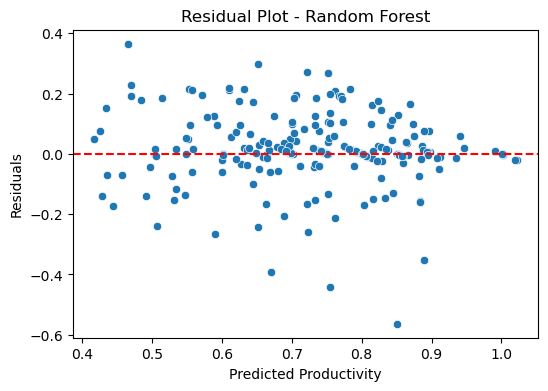

In [61]:
residuals = ytest - y_pred_rf

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(0, linestyle="--", color="red") 

plt.xlabel("Predicted Productivity")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.show()

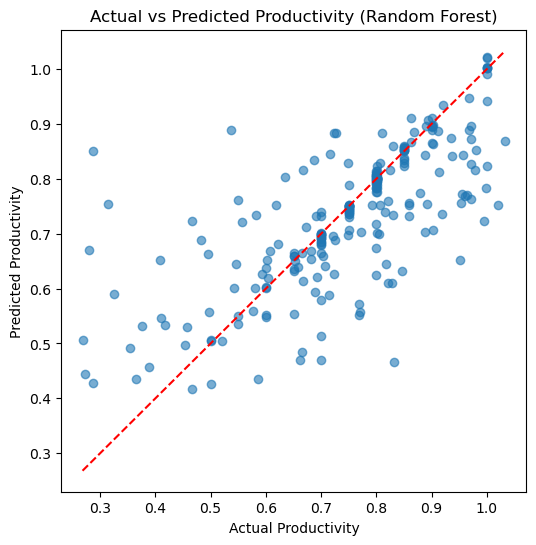

In [62]:
y_pred_rf = best_rf.predict(Xtest)

plt.figure(figsize=(6,6))
plt.scatter(ytest, y_pred_rf, alpha=0.6)

# Line
min_val = min(ytest.min(), y_pred_rf.min())
max_val = max(ytest.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity (Random Forest)")
plt.show()

In [65]:
# 用你 notebook 里最后拿来训练模型的 df
X = df.drop("actual_productivity", axis=1)
y = df["actual_productivity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_model = joblib.load("lin_model.joblib")
ridge_model = joblib.load("ridge_model.joblib")
dt_model = joblib.load("dt_model.joblib")
rf_model = joblib.load("rf_model.joblib")

print("Linear loaded:", lin_model)
print("Ridge loaded:", ridge_model)
print("DT loaded:", dt_model)
print("RF loaded:", rf_model)

print("Linear predict test:", lin_model.predict(X_test[:5]))
print("Ridge predict test:", ridge_model.predict(X_test[:5]))
print("DT predict test:", dt_model.predict(X_test[:5]))
print("RF predict test:", rf_model.predict(X_test[:5]))

Linear loaded: LinearRegression()
Ridge loaded: Ridge(alpha=0.1)
DT loaded: DecisionTreeRegressor(max_depth=7, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)
RF loaded: RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=200,
                      random_state=42)
Linear predict test: [0.62771873 0.77447071 0.79872883 0.76623422 0.7878977 ]
Ridge predict test: [0.62842385 0.77405502 0.79822761 0.76643065 0.7875577 ]
DT predict test: [0.47584145 0.8018012  0.66575447 0.5679375  0.66575447]
RF predict test: [0.50714175 0.79889017 0.65321719 0.58990729 0.61314806]


In [64]:
feature_columns = Xtrain.columns.tolist()
joblib.dump(feature_columns, "feature_columns.joblib")
print("feature_columns.joblib saved successfully")

feature_columns.joblib saved successfully


In [44]:
import os
os.getcwd() 

'C:\\Users\\acer\\anaconda_projects\\22fe23f7-1b4d-436d-861d-ccf978e00d6e'